---
# Curso: Data Mining

# <font color=blue>Limpieza inicial e integración: Seguimiento de Inversiones (MEF) y Proceso de Selección (OSCE)</font>

---

**1. Problema**

El MEF publica el avance financiero de cada proyecto de inversión (cuánto se ha presupuestado y devengado por año), pero esa fuente no dice nada sobre el avance físico real de la obra. Por otro lado, el histórico de procesos de selección sí registra ese avance físico y contractual, pero mes a mes, no un valor único por proyecto. Sin cruzar ambas fuentes es imposible responder algo tan básico como "¿este proyecto ya gastó el 80% de su presupuesto pero la obra recién va en 20% de avance físico?".

El objetivo de este cuaderno es dejar ambas fuentes limpias y construir una base integrada que junte, para cada registro presupuestal del MEF, el estado físico **más reciente** que exista de ese mismo proyecto.

**2. Unidad de análisis**

El proyecto de inversión pública, identificado por su código único de inversión (el mismo código que usa el Banco de Inversiones / Invierte.pe). En `2026_Seguimiento_PI.csv` ese código aparece como `PRODUCTO_PROYECTO`; en `PROCESO_SELECCION.csv` aparece como `CODIGO_UNICO`. No es la misma tabla a nivel de fila: en Seguimiento un proyecto puede repetirse por año, pliego o fuente de financiamiento, y en Proceso_Selección un proyecto se repite por cada mes en que fue reportado.

**3. Fuentes de datos y llave de integración**

| Fuente | Contenido | Llave |
|---|---|---|
| `2026_Seguimiento_PI.csv` (MEF) | Ejecución presupuestal por año fiscal, pliego, ejecutora y fuente de financiamiento | `PRODUCTO_PROYECTO` |
| `PROCESO_SELECCION.csv` | Historial mensual de avance físico y contractual por proyecto | `CODIGO_UNICO` |

La llave de integración es `PRODUCTO_PROYECTO` (Seguimiento) = `CODIGO_UNICO` (Proceso_Selección).

**4. El problema particular de esta integración**

`PROCESO_SELECCION.csv` no tiene una fila por proyecto: tiene una fila por cada mes reportado, y un mismo proyecto puede acumular cientos o miles de filas de historial. Cruzar directamente por el código, sin tratamiento previo, multiplica cada fila del MEF por todas las filas de historial que tenga ese proyecto en Proceso_Selección — una explosión de filas que no aporta nada y que ya nos pasó factura en un intento anterior de este mismo cruce. Lo correcto es quedarnos primero con **una sola fila por proyecto: la del período (mes) más reciente**, y recién ahí integrar esa "fotografía" contra el Seguimiento, que se mantiene intacto.

**Fuentes de datos a integrar:**
Para lograr este análisis, no basta con la información financiera, necesitamos contrastarla con el avance de la obra. Por ello, integramos dos fuentes:
*   **Fuente 1 (MEF):** Seguimiento de Proyectos de Inversión (Datos financieros: PIA, PIM, Devengado). https://fs.datosabiertos.mef.gob.pe/datastorefiles/2026-Seguimiento-PI.csv
*   **Fuente 2 (MEF):** Avance Físico de Obras (Datos físicos: % Avance, Etapa, Valorización). https://fs.datosabiertos.mef.gob.pe/datastorefiles/PROCESO_SELECCION.csv

### <font color=green>1. Importar datos</font>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

RUTA_SEGUIMIENTO = "Seguimiento_PI.csv"
RUTA_PROCESO = "PROCESO_SELECCION.csv"

# SECTOR y PLIEGO se leen como texto porque, según veremos, traen un valor
# centinela (un espacio en blanco) que rompería la detección automática de tipo.
seguimiento = pd.read_csv(RUTA_SEGUIMIENTO, dtype={"SECTOR": str, "PLIEGO": str})

# El archivo de Proceso_Selección viene con BOM (marca de orden de bytes) en la
# cabecera; sin utf-8-sig, la primera columna se leería como '﻿"CODIGO_UNICO"'.
proceso = pd.read_csv(RUTA_PROCESO, encoding="utf-8-sig")

print("Seguimiento_PI:", seguimiento.shape)
print("Proceso_Selección:", proceso.shape)

C:\Users\Fernando\AppData\Local\Temp\ipykernel_17464\3913625553.py:17: DtypeWarning: Columns (0: VAL_META_CAPAC, 1: DES_OBSERVACIONES) have mixed types. Specify dtype option on import or set low_memory=False.
  proceso = pd.read_csv(RUTA_PROCESO, encoding="utf-8-sig")


Seguimiento_PI: (696688, 35)
Proceso_Selección: (5672274, 14)


Ambos archivos son grandes (el de Proceso_Selección pesa más de 1 GB y tiene casi 5.7 millones de filas), así que evitamos cargarlos más de una vez y trabajamos siempre sobre estas dos variables.

### <font color=green>2. Inspección inicial</font>

Revisamos tamaño y tipos detectados por pandas antes de tocar nada.

In [ ]:
print("Tipos de datos en Seguimiento_PI:")
display(seguimiento.dtypes)

Tipos de datos en Seguimiento_PI:


ANO_EJE                                int64
NIVEL_GOBIERNO                           str
NIVEL_GOBIERNO_NOMBRE                    str
SECTOR                                   str
SECTOR_NOMBRE                            str
PLIEGO                                   str
PLIEGO_NOMBRE                            str
SEC_EJEC                               int64
EJECUTORA                              int64
EJECUTORA_NOMBRE                         str
DEPARTAMENTO_EJECUTORA                 int64
DEPARTAMENTO_EJECUTORA_NOMBRE            str
PROVINCIA_EJECUTORA                    int64
PROVINCIA_EJECUTORA_NOMBRE               str
DISTRITO_EJECUTORA                     int64
DISTRITO_EJECUTORA_NOMBRE                str
TIPO_ACT_PROY                          int64
TIPO_ACT_PROY_NOMBRE                     str
PRODUCTO_PROYECTO                      int64
PRODUCTO_PROYECTO_NOMBRE                 str
FUNCION                                int64
FUNCION_NOMBRE                           str
DEPARTAMEN

In [ ]:
print("Tipos de datos en Proceso_Selección:")
display(proceso.dtypes)

Tipos de datos en Proceso_Selección:


CODIGO_UNICO             int64
DES_PRODUCTO               str
DES_ACCION                 str
DES_TIPO_COMPONENTE        str
DES_UM_PRODU               str
VAL_META_PRODU         float64
DES_UM_CAPAC               str
VAL_META_CAPAC          object
COSTO_INVERSION        float64
PERIODO                    str
VALORIZ_ACUM           float64
AVANCE                 float64
DES_OBSERVACIONES          str
DES_ETAPA                  str
dtype: object

`VAL_META_CAPAC` se detectó como texto (`object`) en vez de número, y `SECTOR`/`PLIEGO` los forzamos nosotros a texto para poder inspeccionarlos sin que pandas truene. Ya volvemos sobre esto en la sección de tipos.

### <font color=green>3. Tabla resumen de cada fuente</font>

Antes de buscar problemas puntuales conviene tener un panorama general: cuántos datos hay, cuántos faltan y cuántos valores distintos tiene cada variable. Esto también ayuda a distinguir identificadores (`PRODUCTO_PROYECTO`, `CODIGO_UNICO`) de variables que sí se pueden promediar.

In [ ]:
def tabla_resumen(df, nombre_fuente):
    return pd.DataFrame({
        "fuente": nombre_fuente,
        "variable": df.columns,
        "tipo": df.dtypes.values,
        "n_faltantes": df.isna().sum().values,
        "pct_faltantes": (df.isna().mean() * 100).round(2).values,
        "valores_distintos": df.nunique().values,
        "ejemplo": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
    })

resumen_seguimiento = tabla_resumen(seguimiento, "seguimiento_pi")
resumen_proceso = tabla_resumen(proceso, "proceso_seleccion")

resumen_fuentes = pd.concat([resumen_seguimiento, resumen_proceso], ignore_index=True)
display(resumen_fuentes)

,fuente,variable,tipo,n_faltantes,pct_faltantes,valores_distintos,ejemplo
0,seguimiento_pi,ANO_EJE,int64,0,0.00,22,2005
1,seguimiento_pi,NIVEL_GOBIERNO,str,0,0.00,3,R
2,seguimiento_pi,NIVEL_GOBIERNO_NOMBRE,str,0,0.00,3,GOBIERNOS REGIONALES
3,seguimiento_pi,SECTOR,str,0,0.00,31,99
4,seguimiento_pi,SECTOR_NOMBRE,str,0,0.00,33,GOBIERNOS REGIONALES
5,seguimiento_pi,PLIEGO,str,0,0.00,169,460
6,seguimiento_pi,PLIEGO_NOMBRE,str,0,0.00,233,GOBIERNO REGIONAL TACNA
7,seguimiento_pi,SEC_EJEC,int64,0,0.00,2570,931
8,seguimiento_pi,EJECUTORA,int64,0,0.00,2009,1
9,seguimiento_pi,EJECUTORA_NOMBRE,str,0,0.00,2520,REGION TACNA-SEDE CENTRAL


Un par de cosas saltan a la vista incluso antes de calcular nada más:

- En Seguimiento_PI, `isna()` reporta cero faltantes en todas las columnas, lo cual es sospechoso — probablemente hay valores faltantes disfrazados con algún texto o símbolo en vez de venir vacíos. Lo confirmamos en la siguiente sección.
- En Proceso_Selección, `AVANCE` (nuestra variable de interés para saber qué tan avanzada va la obra) tiene una proporción enorme de faltantes, y `PERIODO` también, lo que va a complicar justamente la tarea de encontrar "el período más reciente".
- `CODIGO_UNICO` tiene muchísimas menos filas únicas que el total de filas del archivo: el mismo proyecto se repite una y otra vez.

### <font color=green>4. Valores faltantes</font>

In [ ]:
print("Faltantes en Seguimiento_PI (conteo directo):")
display(seguimiento.isna().sum())

Faltantes en Seguimiento_PI (conteo directo):


ANO_EJE                              0
NIVEL_GOBIERNO                       0
NIVEL_GOBIERNO_NOMBRE                0
SECTOR                               0
SECTOR_NOMBRE                        0
PLIEGO                               0
PLIEGO_NOMBRE                        0
SEC_EJEC                             0
EJECUTORA                            0
EJECUTORA_NOMBRE                     0
DEPARTAMENTO_EJECUTORA               0
DEPARTAMENTO_EJECUTORA_NOMBRE        0
PROVINCIA_EJECUTORA                  0
PROVINCIA_EJECUTORA_NOMBRE           0
DISTRITO_EJECUTORA                   0
DISTRITO_EJECUTORA_NOMBRE            0
TIPO_ACT_PROY                        0
TIPO_ACT_PROY_NOMBRE                 0
PRODUCTO_PROYECTO                    0
PRODUCTO_PROYECTO_NOMBRE             0
FUNCION                              0
FUNCION_NOMBRE                       0
DEPARTAMENTO_META                    0
DEPARTAMENTO_META_NOMBRE             0
FUENTE_FINANCIAMIENTO                0
FUENTE_FINANCIAMIENTO_NOM

Efectivamente, `isna()` no marca nada como faltante en Seguimiento_PI. Pero al mirar `SECTOR` y `PLIEGO` de cerca aparece el faltante disfrazado: para los gobiernos locales, en vez de dejar la celda vacía, el archivo trae un espacio en blanco (`" "`) porque esas entidades no tienen un sector nacional ni un pliego asignado en la estructura presupuestal.

In [ ]:
print("Valores 'en blanco' (espacio) en SECTOR:", (seguimiento["SECTOR"].str.strip() == "").sum())
print("Valores 'en blanco' (espacio) en PLIEGO:", (seguimiento["PLIEGO"].str.strip() == "").sum())

print("\n¿A qué nivel de gobierno corresponden estas filas?")
display(seguimiento.loc[seguimiento["SECTOR"].str.strip() == "", "NIVEL_GOBIERNO_NOMBRE"].value_counts())

Valores 'en blanco' (espacio) en SECTOR: 616784
Valores 'en blanco' (espacio) en PLIEGO: 616784

¿A qué nivel de gobierno corresponden estas filas?


NIVEL_GOBIERNO_NOMBRE
GOBIERNOS LOCALES    616784
Name: count, dtype: int64

Coincide exactamente con el número de filas de "GOBIERNOS LOCALES": no es un dato faltante por error de captura, es un faltante **estructural** (a un gobierno local simplemente no le corresponde un código de sector nacional). Lo vamos a convertir a `NaN` explícito más adelante, mejor que dejarlo como un espacio que hoy en día ni siquiera se ve en un `value_counts()` normal.

In [ ]:
print("Faltantes en Proceso_Selección:")
faltantes_proceso = pd.DataFrame({
    "n_faltantes": proceso.isna().sum(),
    "pct_faltantes": (proceso.isna().mean() * 100).round(2),
})
display(faltantes_proceso)

Faltantes en Proceso_Selección:


,n_faltantes,pct_faltantes
CODIGO_UNICO,0,0.00
DES_PRODUCTO,96074,1.69
DES_ACCION,585703,10.33
DES_TIPO_COMPONENTE,490675,8.65
DES_UM_PRODU,1464212,25.81
VAL_META_PRODU,1177544,20.76
DES_UM_CAPAC,2791006,49.20
VAL_META_CAPAC,1450097,25.56
COSTO_INVERSION,510,0.01
PERIODO,1418376,25.01


`AVANCE` falta en cerca del 90% de las filas y `PERIODO` en alrededor de una de cada cuatro. Esto ya nos avisa que, cuando busquemos "el período más reciente" por proyecto, un grupo de proyectos no va a tener ningún período válido del cual partir — hay que tener un plan para esos casos, no simplemente ignorarlos.

### <font color=green>5. Categorías y errores de registro</font>

Revisamos las variables categóricas más relevantes para el análisis posterior: la etapa del proyecto, el tipo de componente y el nivel de gobierno.

In [ ]:
print("Valores de DES_ETAPA:")
display(proceso["DES_ETAPA"].value_counts(dropna=False))

Valores de DES_ETAPA:


DES_ETAPA
CONSISTENCIA              1193602
Ejecución física (C)      1158941
Expediente técnico (B)    1001091
FYE                        981359
EJECUCION                  648548
CRONOGRAMA                 375734
CONTRACTUAL                312999
Name: count, dtype: int64

`DES_ETAPA` mezcla dos convenciones de escritura distintas para lo que en el fondo es la misma idea (una etapa del ciclo del proyecto): algunas categorías están en mayúsculas y sin tilde (`EJECUCION`, `CONTRACTUAL`), y otras llegan con mayúsculas y minúsculas mezcladas, tilde y hasta un código entre paréntesis (`Expediente técnico (B)`, `Ejecución física (C)`). Si no se homologa, cualquier conteo por etapa va a separar categorías que en realidad son la misma cosa escrita distinto.

In [ ]:
print("Valores de DES_TIPO_COMPONENTE:")
display(proceso["DES_TIPO_COMPONENTE"].value_counts(dropna=False))

print("\nValores de NIVEL_GOBIERNO_NOMBRE:")
display(seguimiento["NIVEL_GOBIERNO_NOMBRE"].value_counts(dropna=False))

Valores de DES_TIPO_COMPONENTE:


DES_TIPO_COMPONENTE
INFRAESTRUCTURA            3674595
INTANGIBLES                 872365
NaN                         490675
EQUIPAMIENTO                391706
MOBILIARIO                  148036
INFRAESTRUCTURA NATURAL      44376
VEHICULOS                    40057
TERRENOS                     10127
GESTIÓN DEL PROGRAMA           298
ESTUDIO BASE                    39
Name: count, dtype: int64


Valores de NIVEL_GOBIERNO_NOMBRE:


NIVEL_GOBIERNO_NOMBRE
GOBIERNOS LOCALES       616784
GOBIERNOS REGIONALES     42349
GOBIERNO NACIONAL        37555
Name: count, dtype: int64

`DES_TIPO_COMPONENTE` está razonablemente estandarizado (todo en mayúsculas), así que lo dejamos como está. `NIVEL_GOBIERNO_NOMBRE` tampoco muestra inconsistencias de escritura.

### <font color=green>6. Duplicados</font>

In [ ]:
print("Filas duplicadas exactas en Seguimiento_PI:", seguimiento.duplicated().sum())
print("Filas duplicadas exactas en Proceso_Selección:", proceso.duplicated().sum())

Filas duplicadas exactas en Seguimiento_PI: 0
Filas duplicadas exactas en Proceso_Selección: 113068


Seguimiento_PI no tiene duplicados exactos. Proceso_Selección sí: más de 100 mil filas están repetidas de principio a fin. Un ejemplo:

In [ ]:
ejemplo_dup = proceso[proceso.duplicated(keep=False)].sort_values("CODIGO_UNICO")
display(ejemplo_dup.head(4))

,CODIGO_UNICO,DES_PRODUCTO,DES_ACCION,DES_TIPO_COMPONENTE,DES_UM_PRODU,VAL_META_PRODU,DES_UM_CAPAC,VAL_META_CAPAC,COSTO_INVERSION,PERIODO,VALORIZ_ACUM,AVANCE,DES_OBSERVACIONES,DES_ETAPA
3884299,2002060,RED VIAL CARRETERA TINGO MARÍA- AGUAYTÍA- PUCA...,Inventario físico Covid - 19,INFRAESTRUCTURA,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,Ejecución física (C)
3884298,2002060,RED VIAL CARRETERA TINGO MARÍA- AGUAYTÍA- PUCA...,Gastos Generales por Covid - 19,INFRAESTRUCTURA,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,Ejecución física (C)
2009451,2002060,RED VIAL CARRETERA TINGO MARÍA- AGUAYTÍA- PUCA...,Gastos Generales por Covid - 19,INFRAESTRUCTURA,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,Ejecución física (C)
2009452,2002060,RED VIAL CARRETERA TINGO MARÍA- AGUAYTÍA- PUCA...,Inventario físico Covid - 19,INFRAESTRUCTURA,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,Ejecución física (C)


Esto no tiene nada que ver con el historial mensual (que es una repetición *legítima* del código a lo largo del tiempo): son literalmente la misma fila cargada dos veces, con el mismo período y el mismo valor en todas las columnas. Eso sí se elimina.

Aparte de los duplicados exactos, `CODIGO_UNICO` se repite muchísimo por diseño — es el historial de seguimiento del proyecto, no un error:

In [ ]:
filas_por_proyecto = proceso.groupby("CODIGO_UNICO").size()
print("Proyectos distintos en Proceso_Selección:", proceso["CODIGO_UNICO"].nunique())
print("Filas por proyecto (resumen):")
display(filas_por_proyecto.describe())
print("Proyecto con más historial:", filas_por_proyecto.idxmax(), "->", filas_por_proyecto.max(), "filas")

Proyectos distintos en Proceso_Selección: 204162
Filas por proyecto (resumen):


count    204162.000000
mean         27.783202
std          76.299192
min           1.000000
25%           5.000000
50%          12.000000
75%          30.000000
max        7662.000000
dtype: float64

Proyecto con más historial: 2307923 -> 7662 filas


En promedio cada proyecto acumula cerca de 28 filas de historial, y el caso extremo llega a más de 7,600. Este es justamente el motivo por el que no se puede cruzar directo contra Seguimiento_PI sin antes reducir cada proyecto a una sola fila.

### <font color=green>7. Conversión de tipos</font>

Convertimos las columnas que deberían ser numéricas o de fecha y que pandas detectó como texto.

In [ ]:
# SECTOR / PLIEGO: el espacio en blanco es el faltante estructural que ya identificamos.
seguimiento["SECTOR"] = seguimiento["SECTOR"].replace(r"^\s*$", np.nan, regex=True)
seguimiento["PLIEGO"] = seguimiento["PLIEGO"].replace(r"^\s*$", np.nan, regex=True)
seguimiento["SECTOR"] = pd.to_numeric(seguimiento["SECTOR"], errors="coerce")
seguimiento["PLIEGO"] = pd.to_numeric(seguimiento["PLIEGO"], errors="coerce")

# VAL_META_CAPAC usa coma decimal en vez de punto (formato regional), por eso
# pandas la leyó como texto.
proceso["VAL_META_CAPAC"] = pd.to_numeric(
    proceso["VAL_META_CAPAC"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce",
)

# PERIODO viene como texto "AAAA-MM"; lo pasamos a fecha para poder ordenar
# cronológicamente y quedarnos con el más reciente por proyecto.
proceso["PERIODO_FECHA"] = pd.to_datetime(proceso["PERIODO"], format="%Y-%m", errors="coerce")

print("SECTOR/PLIEGO ahora son numéricos:")
display(seguimiento[["SECTOR", "PLIEGO"]].dtypes)
print("\nVAL_META_CAPAC ahora es:", proceso["VAL_META_CAPAC"].dtype)
print("PERIODO_FECHA ahora es:", proceso["PERIODO_FECHA"].dtype)
print("Filas donde PERIODO no se pudo interpretar como fecha:", proceso["PERIODO_FECHA"].isna().sum(),
      "de", len(proceso))

SECTOR/PLIEGO ahora son numéricos:


SECTOR    float64
PLIEGO    float64
dtype: object


VAL_META_CAPAC ahora es: float64
PERIODO_FECHA ahora es: datetime64[us]
Filas donde PERIODO no se pudo interpretar como fecha: 1465701 de 5672274


El total de fechas no interpretables (cerca de 1.5 millones, poco más de una cuarta parte del total) incluye tanto los `PERIODO` que ya venían vacíos como algunos textos con un formato distinto a "AAAA-MM" que `errors="coerce"` convierte directamente en faltante para poder tratarlos junto con el resto.

### <font color=green>8. Valores fuera de rango</font>

`AVANCE` debería ser un porcentaje (0 a 100), `COSTO_INVERSION` no debería ser negativo, y `PERIODO_FECHA` no debería caer en el futuro respecto a la fecha de hoy.

In [ ]:
hoy = pd.Timestamp("2026-08-19")

fuera_avance = (proceso["AVANCE"] < 0) | (proceso["AVANCE"] > 100)
fuera_costo = proceso["COSTO_INVERSION"] < 0
fuera_periodo = proceso["PERIODO_FECHA"] > hoy

print("AVANCE fuera de 0-100:", fuera_avance.sum())
print("Ejemplos de AVANCE fuera de rango (debería ser %):")
print(proceso.loc[fuera_avance, "AVANCE"].sort_values(ascending=False).head(5).tolist())

print("\nCOSTO_INVERSION negativo:", fuera_costo.sum())
print("Ejemplos:", proceso.loc[fuera_costo, "COSTO_INVERSION"].head(5).tolist())

print("\nPERIODO en el futuro (posterior a hoy):", fuera_periodo.sum())
print("Años involucrados:")
display(proceso.loc[fuera_periodo, "PERIODO_FECHA"].dt.year.value_counts().sort_index())

AVANCE fuera de 0-100: 6090
Ejemplos de AVANCE fuera de rango (debería ser %):
[101430732621156.0, 95237684.0, 72356238.37, 43453790.34, 35079512.14]

COSTO_INVERSION negativo: 1030
Ejemplos: [-418.43, -418.43, -308.61, -308.61, -36894.81]

PERIODO en el futuro (posterior a hoy): 149272
Años involucrados:


PERIODO_FECHA
2026    57918
2027    65594
2028    16044
2029     5908
2030     1499
2031      559
2032      627
2033      200
2034      124
2035      528
2036      133
2037       94
2038       23
2039        6
2040       14
2041        1
Name: count, dtype: int64

Los valores de `AVANCE` que llegan a millones (hasta el orden de 10¹⁴) no son un porcentaje mal calculado: son un problema de mezcla de escalas, como si en algunas filas se hubiera guardado un monto en soles en la misma columna pensada para un porcentaje. `COSTO_INVERSION` negativo tampoco tiene sentido para una inversión. Y llama la atención un grupo de filas con `PERIODO` fechado hasta el año 2041 — quince años en el futuro respecto a hoy —, seguramente un error de digitación en el mes o el año.

Revisamos también el lado de Seguimiento_PI:

In [ ]:
print("MONTO_EJECUCION_TOTAL negativo:", (seguimiento["MONTO_EJECUCION_TOTAL"] < 0).sum())
display(seguimiento.loc[seguimiento["MONTO_EJECUCION_TOTAL"] < 0, "MONTO_EJECUCION_TOTAL"])

print("\nCOSTO_ACTUAL igual a 0:", (seguimiento["COSTO_ACTUAL"] == 0).mean() * 100, "% de las filas")

MONTO_EJECUCION_TOTAL negativo: 5


5031    -231273.00
7602    -283502.90
34757   -309783.00
38247   -787303.98
41342   -321601.00
Name: MONTO_EJECUCION_TOTAL, dtype: float64


COSTO_ACTUAL igual a 0: 70.0959396458673 % de las filas


`MONTO_EJECUCION_TOTAL` negativo son apenas 5 filas — probablemente reversiones contables, no un error masivo, así que las dejamos marcadas pero no las tocamos. `COSTO_ACTUAL`, en cambio, es cero en el 70% de las filas: no es un error, es una variable que casi no aporta información en esta fuente, así que no la vamos a usar más adelante (no la eliminamos del dataframe para no alterar Seguimiento_PI, simplemente no la explotamos en el análisis).

Un vistazo visual a `AVANCE` (ya sin los valores imposibles) y a `COSTO_INVERSION` ayuda a decidir qué tan agresivos ser con el resto de outliers:

C:\Users\Fernando\AppData\Local\Temp\ipykernel_17464\3481582310.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(np.log10(costo_valido), vert=True)


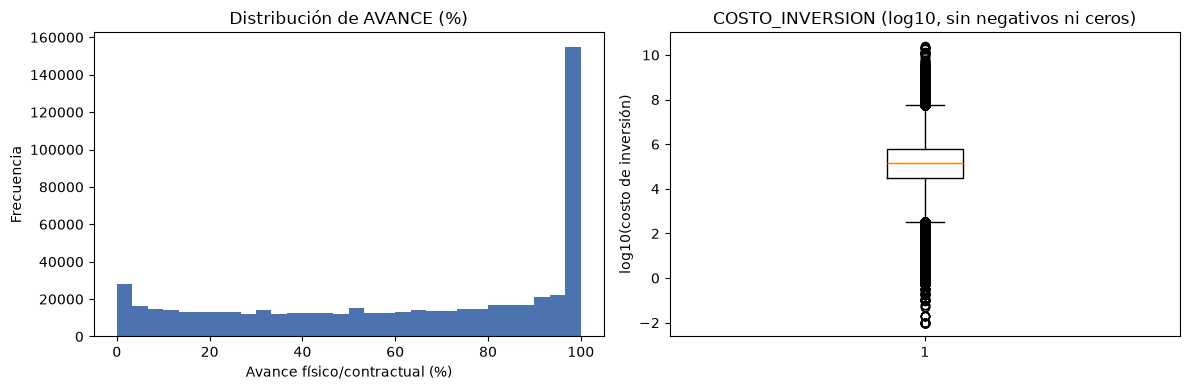

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

avance_valido = proceso.loc[~fuera_avance, "AVANCE"].dropna()
axes[0].hist(avance_valido, bins=30, color="#4C72B0")
axes[0].set_title("Distribución de AVANCE (%)")
axes[0].set_xlabel("Avance físico/contractual (%)")
axes[0].set_ylabel("Frecuencia")

costo_valido = proceso.loc[(proceso["COSTO_INVERSION"] > 0), "COSTO_INVERSION"].dropna()
axes[1].boxplot(np.log10(costo_valido), vert=True)
axes[1].set_title("COSTO_INVERSION (log10, sin negativos ni ceros)")
axes[1].set_ylabel("log10(costo de inversión)")

plt.tight_layout()
plt.show()

`AVANCE` está bastante concentrado hacia valores altos (muchos proyectos reportan avances de 70-100%), y `COSTO_INVERSION` en escala logarítmica muestra la cola larga típica de montos de inversión pública: unos pocos proyectos gigantes conviven con una mayoría de proyectos pequeños. No vemos evidencia de que haya que recortar más outliers "razonables" además de los valores ya imposibles detectados arriba.

### <font color=green>9. Tratamiento de valores inválidos y faltantes</font>

Con los problemas ya identificados, aplicamos las correcciones: los valores imposibles se convierten en faltantes explícitos (no los inventamos, no los imputamos a la fuerza) y homologamos las categorías de `DES_ETAPA`.

In [ ]:
# Eliminar duplicados exactos en Proceso_Selección
proceso = proceso.drop_duplicates().copy()
print("Proceso_Selección sin duplicados exactos:", proceso.shape)

# Valores imposibles -> faltante explícito
proceso.loc[fuera_avance.reindex(proceso.index, fill_value=False), "AVANCE"] = np.nan
proceso.loc[proceso["COSTO_INVERSION"] < 0, "COSTO_INVERSION"] = np.nan
proceso.loc[proceso["PERIODO_FECHA"] > hoy, "PERIODO_FECHA"] = pd.NaT

# Homologar DES_ETAPA a una sola convención: mayúsculas, sin tildes
proceso["DES_ETAPA"] = (
    proceso["DES_ETAPA"].astype(str).str.upper()
    .str.normalize("NFKD").str.encode("ascii", "ignore").str.decode("ascii")
    .str.strip()
)

print("\nDES_ETAPA homologado:")
display(proceso["DES_ETAPA"].value_counts())

Proceso_Selección sin duplicados exactos: (5559193, 15)

DES_ETAPA homologado:


DES_ETAPA
CONSISTENCIA              1192706
EJECUCION FISICA (C)      1049581
EXPEDIENTE TECNICO (B)     999732
FYE                        980885
EJECUCION                  648305
CRONOGRAMA                 375219
CONTRACTUAL                312765
Name: count, dtype: int64

No imputamos `AVANCE` con una media o mediana: es la variable que justamente vamos a usar para comparar contra la ejecución presupuestal, e inventar un valor ahí distorsionaría exactamente lo que queremos medir. Preferimos dejarlo como faltante y que quede visible como tal en la base final, en vez de un promedio artificial que dé una falsa sensación de completitud.

### <font color=green>10. Selección del período más reciente por proyecto</font>

Este es el paso que evita la explosión de filas: en vez de cruzar Seguimiento_PI contra las más de 5 millones de filas de Proceso_Selección, construimos primero una tabla de una sola fila por `CODIGO_UNICO`, con el registro de período más reciente.

No todos los proyectos tienen un `PERIODO` válido (algunos lo tienen siempre vacío), así que separamos en dos grupos y tratamos cada uno con una regla explícita.

In [ ]:
con_periodo = proceso[proceso["PERIODO_FECHA"].notna()].copy()
sin_periodo = proceso[proceso["PERIODO_FECHA"].isna()].copy()

codigos_con_periodo = set(con_periodo["CODIGO_UNICO"].unique())
codigos_totales = set(proceso["CODIGO_UNICO"].unique())
codigos_sin_periodo = codigos_totales - codigos_con_periodo

print("Proyectos con al menos un período válido:", len(codigos_con_periodo))
print("Proyectos sin ningún período válido:", len(codigos_sin_periodo))

Proyectos con al menos un período válido: 191729
Proyectos sin ningún período válido: 12433


In [ ]:
# Grupo 1: para cada proyecto con historial, nos quedamos con la fila del
# período más reciente (ordenamos por fecha y tomamos el último registro).
con_periodo = con_periodo.sort_values("PERIODO_FECHA")
snapshot_reciente = con_periodo.drop_duplicates(subset="CODIGO_UNICO", keep="last").copy()
snapshot_reciente["PERIODO_DISPONIBLE"] = True

# Grupo 2: proyectos que nunca tuvieron un período interpretable. No podemos
# decir cuál es "el más reciente", así que nos quedamos con su último registro
# tal como aparece en el archivo y lo dejamos marcado como tal — no se descarta
# el proyecto, pero sí queda claro que el dato de período no es confiable.
sin_periodo_agg = sin_periodo[~sin_periodo["CODIGO_UNICO"].isin(codigos_con_periodo)].copy()
sin_periodo_agg = sin_periodo_agg.drop_duplicates(subset="CODIGO_UNICO", keep="last").copy()
sin_periodo_agg["PERIODO_DISPONIBLE"] = False

snapshot_proceso = pd.concat([snapshot_reciente, sin_periodo_agg], ignore_index=True)

print("Snapshot final:", snapshot_proceso.shape)
print("¿Una sola fila por proyecto?", snapshot_proceso["CODIGO_UNICO"].is_unique)
print("\nProporción de proyectos con período confiable:",
      round(snapshot_proceso["PERIODO_DISPONIBLE"].mean() * 100, 2), "%")

Snapshot final: (204162, 16)
¿Una sola fila por proyecto? True

Proporción de proyectos con período confiable: 93.91 %


`snapshot_proceso` tiene ahora exactamente una fila por cada uno de los proyectos que aparecen en Proceso_Selección: para más del 93% viene de un período real (el más reciente que reportaron), y para el resto queda marcado con `PERIODO_DISPONIBLE = False` para que no se confunda con un dato verificado. Esta es la tabla que vamos a cruzar contra Seguimiento_PI — no el archivo original.

### <font color=green>11. Integración</font>

Cruzamos con `how="left"` para mantener intacto Seguimiento_PI (todas sus filas, sin filtrar ni deduplicar) y sumarle, donde exista, la fotografía más reciente del avance físico/contractual.

In [ ]:
base_integrada = pd.merge(
    seguimiento,
    snapshot_proceso,
    left_on="PRODUCTO_PROYECTO",
    right_on="CODIGO_UNICO",
    how="left",
    suffixes=("_seguimiento", "_proceso"),
    indicator=True,
)

print("Seguimiento_PI original:", seguimiento.shape)
print("Base integrada:", base_integrada.shape)
print("\n¿Se mantuvo el mismo número de filas que Seguimiento_PI?",
      base_integrada.shape[0] == seguimiento.shape[0])

display(base_integrada["_merge"].value_counts())

Seguimiento_PI original: (696688, 35)
Base integrada: (696688, 52)

¿Se mantuvo el mismo número de filas que Seguimiento_PI? True


_merge
left_only     524199
both          172489
right_only         0
Name: count, dtype: int64

El número de filas de `base_integrada` es idéntico al de `seguimiento`: la integración no duplicó ni perdió ningún registro del MEF, que era justo la condición de partida.

### <font color=green>12. Validación del resultado de la integración</font>

In [ ]:
tasa_match = (base_integrada["_merge"] == "both").mean() * 100
print(f"Filas de Seguimiento_PI con match en Proceso_Selección: {tasa_match:.2f}%")

proyectos_seguimiento = set(seguimiento["PRODUCTO_PROYECTO"].unique())
proyectos_proceso = set(proceso["CODIGO_UNICO"].unique())
interseccion = proyectos_seguimiento & proyectos_proceso

print(f"\nProyectos distintos en Seguimiento_PI: {len(proyectos_seguimiento)}")
print(f"Proyectos distintos en Proceso_Selección: {len(proyectos_proceso)}")
print(f"Proyectos que existen en ambas fuentes: {len(interseccion)} "
      f"({len(interseccion) / len(proyectos_seguimiento) * 100:.1f}% de los de Seguimiento_PI)")

Filas de Seguimiento_PI con match en Proceso_Selección: 24.76%

Proyectos distintos en Seguimiento_PI: 52677
Proyectos distintos en Proceso_Selección: 204162
Proyectos que existen en ambas fuentes: 35475 (67.3% de los de Seguimiento_PI)


Aquí aparece un matiz que vale la pena dejar anotado: a nivel de **proyecto**, la coincidencia entre fuentes ronda el 67%, pero a nivel de **fila** el match baja a poco menos de la cuarta parte. La explicación es que Seguimiento_PI no tiene una fila por proyecto, sino varias (por año, pliego o fuente de financiamiento), y los proyectos que no aparecen en Proceso_Selección resultan ser, en promedio, los que más se repiten dentro de Seguimiento_PI — probablemente proyectos más antiguos o de menor envergadura que nunca pasaron por un proceso de selección registrado en esta fuente. Es una diferencia real entre "cobertura por proyecto" y "cobertura por fila" que conviene tener presente antes de sacar conclusiones agregadas con la base integrada.

In [ ]:
print("Tipos de datos finales (columnas clave):")
display(base_integrada[["PRODUCTO_PROYECTO", "CODIGO_UNICO", "AVANCE", "COSTO_INVERSION",
                          "PERIODO_FECHA", "PERIODO_DISPONIBLE", "DES_ETAPA"]].dtypes)

print("\nFaltantes en las columnas incorporadas desde Proceso_Selección:")
display(base_integrada[["AVANCE", "COSTO_INVERSION", "DES_ETAPA", "PERIODO_FECHA"]].isna().sum())

Tipos de datos finales (columnas clave):


PRODUCTO_PROYECTO              int64
CODIGO_UNICO                 float64
AVANCE                       float64
COSTO_INVERSION              float64
PERIODO_FECHA         datetime64[us]
PERIODO_DISPONIBLE            object
DES_ETAPA                        str
dtype: object


Faltantes en las columnas incorporadas desde Proceso_Selección:


AVANCE             680963
COSTO_INVERSION    524438
DES_ETAPA          524199
PERIODO_FECHA      526415
dtype: int64

Los faltantes en estas columnas combinan dos cosas distintas y no hay que confundirlas: filas sin match (`left_only`, el proyecto de Seguimiento_PI no tiene registro en Proceso_Selección) y filas con match pero donde `AVANCE` u otra columna venían vacías desde el propio Proceso_Selección. Documentarlo así evita interpretar un "no aplica" como si fuera un dato perdido por error.

### <font color=green>13. Diccionario de datos</font>

Ya habíamos preparado un diccionario de datos para estas dos fuentes (`diccionario_de_datos_entregable.xlsx`); lo cargamos aquí en vez de rehacerlo desde cero.

In [ ]:
diccionario = pd.read_excel("diccionario_de_datos_entregable.xlsx")
print("Variables documentadas por fuente:")
display(diccionario["fuente"].value_counts())
display(diccionario.head(10))

Variables documentadas por fuente:


fuente
mef_seguimiento_financiero    35
mef_2_avance_fisico           14
Name: count, dtype: int64

,variable,fuente,descripcion,tipo_general,escala,rol_o_subtipo,observaciones
0,ANO_EJE,mef_seguimiento_financiero,Año de ejecución del presupuesto.,Numérica,Intervalo,Discreta (Fecha),NaN
1,NIVEL_GOBIERNO,mef_seguimiento_financiero,"Código que identifica el Nivel de Gobierno: E,...",Categórica,Nominal,Código agrupador,NaN
2,NIVEL_GOBIERNO_NOMBRE,mef_seguimiento_financiero,"Descripción de Nivel de Gobierno: Nacional, Re...",Texto,Nominal,Texto descriptivo,NaN
3,SECTOR,mef_seguimiento_financiero,Código de Sector al que pertenece la Entidad.,Categórica,Nominal,Código agrupador,NaN
4,SECTOR_NOMBRE,mef_seguimiento_financiero,Descripción de código del Sector al que perten...,Texto,Nominal,Texto descriptivo,NaN
5,PLIEGO,mef_seguimiento_financiero,Código de Pliego al que pertenece la Entidad.,Categórica,Nominal,Código agrupador,NaN
6,PLIEGO_NOMBRE,mef_seguimiento_financiero,Descripción de código del Pliego al que perten...,Texto,Nominal,Texto descriptivo,NaN
7,SEC_EJEC,mef_seguimiento_financiero,Código que identifica a una Entidad.,Categórica,Nominal,Identificador de entidad,NaN
8,EJECUTORA,mef_seguimiento_financiero,Código institucional que identifica a una Enti...,Categórica,Nominal,Identificador de entidad,NaN
9,EJECUTORA_NOMBRE,mef_seguimiento_financiero,Nombre de la Entidad.,Texto,Nominal,Texto descriptivo,NaN


### <font color=green>14. Decisiones de limpieza justificadas</font>

In [ ]:
decisiones = pd.DataFrame([
    ["SECTOR / PLIEGO", "Faltante disfrazado como espacio en blanco", "Convertir espacio a NaN y castear a numérico",
     "Es un faltante estructural (gobiernos locales no tienen sector nacional), no un error; mejor dejarlo como NaN explícito que como texto vacío invisible."],
    ["DES_ETAPA", "Dos convenciones de escritura para la misma categoría", "Homologar a mayúsculas sin tilde",
     "Evita que 'EJECUCION' y 'Ejecución física (C)' (etapas distintas pero con el mismo prefijo) se cuenten de forma inconsistente por simple diferencia de formato."],
    ["VAL_META_CAPAC", "Texto por uso de coma decimal", "Reemplazar coma por punto y convertir a número",
     "Formato regional de escritura de decimales; no es un valor inválido, solo mal interpretado por pandas."],
    ["PERIODO", "Texto 'AAAA-MM', ~25% vacío y algunos años a futuro (hasta 2041)", "Convertir a fecha con errors='coerce' y marcar como faltante lo posterior a hoy",
     "Un período fechado 15 años a futuro no puede ser el 'más reciente' real; tratarlo como dato perdido es más seguro que usarlo tal cual."],
    ["AVANCE", "Valores fuera de 0-100 (hasta el orden de 10^14)", "Convertir a NaN, sin imputar",
     "Es la variable que se usará para contrastar avance físico contra ejecución presupuestal; imputar aquí sesgaría justo lo que se quiere medir."],
    ["COSTO_INVERSION", "Valores negativos", "Convertir a NaN", "Un costo de inversión negativo no tiene interpretación válida en este contexto."],
    ["Proceso_Selección (filas)", "113,068 duplicados exactos", "drop_duplicates()", "Mismo período, mismo proyecto, mismos valores en todas las columnas: es una carga duplicada, no historial legítimo."],
    ["CODIGO_UNICO (repetición)", "Un proyecto puede tener miles de filas de historial mensual", "Reducir a una sola fila por proyecto (la del período más reciente) antes de integrar",
     "Cruzar directo multiplicaba cada fila de Seguimiento_PI por todo el historial del proyecto; la pregunta de negocio solo necesita la fotografía más reciente."],
    ["COSTO_ACTUAL", "70% de las filas en cero", "Se conserva en la base pero no se usa como variable de análisis",
     "No es un error de captura, pero aporta muy poca información distintiva para este análisis."],
    ["Seguimiento_PI (filas)", "N/A", "Se mantiene intacto (how='left', sin deduplicar ni filtrar)",
     "Es la fuente que define la unidad de análisis final; el objetivo era enriquecerla, no reducirla."],
], columns=["variable", "problema", "decisión", "justificación"])

display(decisiones)

,variable,problema,decisión,justificación
0,SECTOR / PLIEGO,Faltante disfrazado como espacio en blanco,Convertir espacio a NaN y castear a numérico,Es un faltante estructural (gobiernos locales ...
1,DES_ETAPA,Dos convenciones de escritura para la misma ca...,Homologar a mayúsculas sin tilde,Evita que 'EJECUCION' y 'Ejecución física (C)'...
2,VAL_META_CAPAC,Texto por uso de coma decimal,Reemplazar coma por punto y convertir a número,Formato regional de escritura de decimales; no...
3,PERIODO,"Texto 'AAAA-MM', ~25% vacío y algunos años a f...",Convertir a fecha con errors='coerce' y marcar...,Un período fechado 15 años a futuro no puede s...
4,AVANCE,Valores fuera de 0-100 (hasta el orden de 10^14),"Convertir a NaN, sin imputar",Es la variable que se usará para contrastar av...
5,COSTO_INVERSION,Valores negativos,Convertir a NaN,Un costo de inversión negativo no tiene interp...
6,Proceso_Selección (filas),"113,068 duplicados exactos",drop_duplicates(),"Mismo período, mismo proyecto, mismos valores ..."
7,CODIGO_UNICO (repetición),Un proyecto puede tener miles de filas de hist...,Reducir a una sola fila por proyecto (la del p...,Cruzar directo multiplicaba cada fila de Segui...
8,COSTO_ACTUAL,70% de las filas en cero,Se conserva en la base pero no se usa como var...,"No es un error de captura, pero aporta muy poc..."
9,Seguimiento_PI (filas),N/A,"Se mantiene intacto (how='left', sin deduplica...",Es la fuente que define la unidad de análisis ...


### <font color=green>15. Exportar resultados</font>

La base integrada completa (con sus ~697 mil filas y 52 columnas) se guarda en CSV, que no tiene límite práctico de tamaño. Para el archivo de Excel usamos una muestra de 100 mil filas en vez de la base completa: no es por el límite de filas de Excel (la base entra sin problema), sino porque un libro de Excel con esa cantidad de columnas y filas se vuelve pesado de abrir y de manipular; la muestra alcanza para revisar rápido el resultado sin cargar el archivo completo cada vez.

In [ ]:
base_integrada.to_csv("base_integrada_seguimiento_proceso.csv", index=False)

with pd.ExcelWriter("resumen_limpieza_seguimiento_proceso.xlsx") as writer:
    resumen_fuentes.to_excel(writer, sheet_name="resumen_fuentes", index=False)
    decisiones.to_excel(writer, sheet_name="decisiones_limpieza", index=False)
    base_integrada.sample(min(100_000, len(base_integrada)), random_state=42).to_excel(
        writer, sheet_name="muestra_base_integrada", index=False
    )

print("Archivos exportados:")
print("- base_integrada_seguimiento_proceso.csv (base completa,", base_integrada.shape, ")")
print("- resumen_limpieza_seguimiento_proceso.xlsx (resumen, decisiones y muestra de 100k filas)")

Archivos exportados:
- base_integrada_seguimiento_proceso.csv (base completa, (696688, 52) )
- resumen_limpieza_seguimiento_proceso.xlsx (resumen, decisiones y muestra de 100k filas)


### Resumen

Seguimiento_PI queda intacto en número de filas; lo que cambia es que ahora trae, cuando existe, el estado físico/contractual más reciente del mismo proyecto.